# Introduction to spaital data 



This workbook walks through a series of examples plotting different types of vector spatial data. For background information refer to [Section 2 of the Intermediate Earth Science Data Textbook](https://earthdatascience.org/courses/use-data-open-source-python/intro-vector-data-python/)

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl 
import pandas as pd 
import numpy as np
import geopandas as gpd
import fiona
from shapely.geometry import Point
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar


1. Before we get started download the USGS Gauges dataset
from here: [USGS Gauges II](https://water.usgs.gov/GIS/metadata/usgswrd/XML/gagesII_Sept2011.xml#stdorder)
2. Save this shapefile in a folder where you are doing your work

In [3]:
# Reading it using geopandas
file =  os.path.join('Data', 'gagesII_9322_sept30_2011.shp')
    #/workspaces/hwrs564b_course_materials_tracy/mywork/content_weekly/Week7_Geospatial/Data/gagesII_9322_sept30_2011.shp
gages = gpd.read_file(file)

# Lets checkout what we just got: 
# This is basically just a regular pandas dataframe but it has geometry
print(type(gages))
print(gages.head())
print(gages.columns)
print(gages.shape) #seeing how many entries there are



<class 'geopandas.geodataframe.GeoDataFrame'>
      STAID                               STANAME    CLASS AGGECOREGI  \
0  01011000   Allagash River near Allagash, Maine  Non-ref  NorthEast   
1  01013500      Fish River near Fort Kent, Maine      Ref  NorthEast   
2  01015800  Aroostook River near Masardis, Maine  Non-ref  NorthEast   
3  01016500        MACHIAS RIVER NEAR ASHLAND, ME  Non-ref  NorthEast   
4  01017000    Aroostook River at Washburn, Maine  Non-ref  NorthEast   

   DRAIN_SQKM HUC02   LAT_GAGE   LNG_GAGE STATE HCDN_2009 ACTIVE09  FLYRS1900  \
0   3186.8440    01  47.069611 -69.079544    ME       NaN      yes       78.0   
1   2252.6960    01  47.237394 -68.582642    ME       yes      yes       85.0   
2   2313.7550    01  46.523003 -68.371764    ME       NaN      yes       51.0   
3    847.7721    01  46.628311 -68.434792    ME       NaN      NaN       32.0   
4   4278.9070    01  46.777294 -68.157194    ME       NaN      yes       79.0   

   FLYRS1950  FLYRS1990     

In [4]:
# Can see the geometry type of each row like this: 
print(gages.geom_type)
# can see the projection here
print(gages.crs)
# And the total spatial extent like this:
print(gages.total_bounds)

0       Point
1       Point
2       Point
3       Point
4       Point
        ...  
9317    Point
9318    Point
9319    Point
9320    Point
9321    Point
Length: 9322, dtype: str
PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
[-6233388.56058375   -47038.09643057  3271609.30400335  6043893.69025059]


## Now do some plotting!

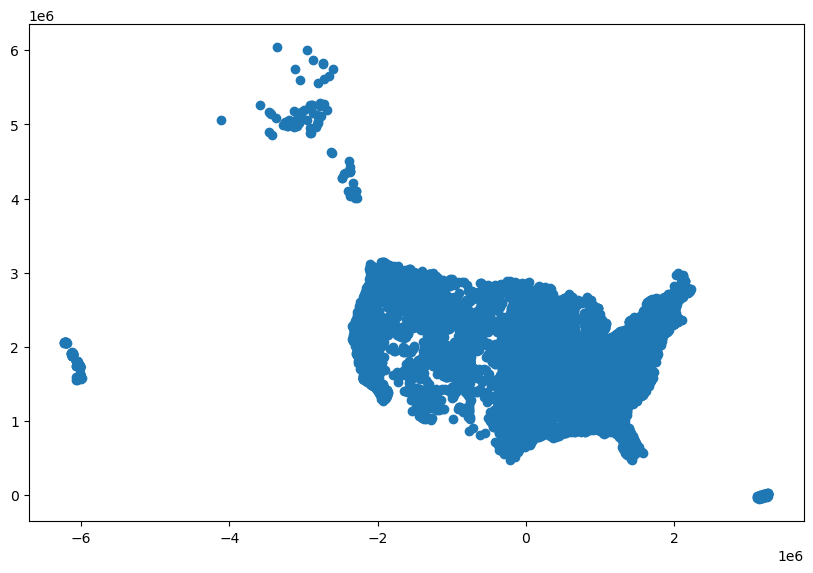

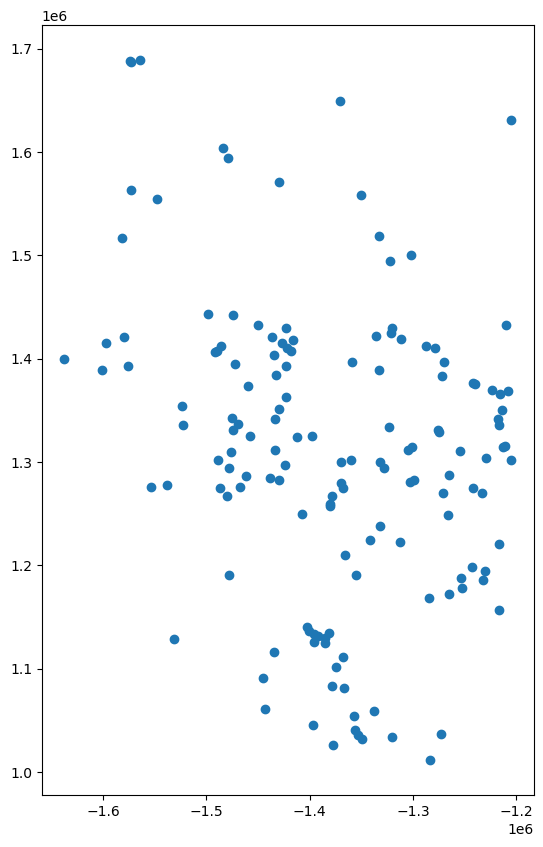

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
gages.plot(ax=ax)
plt.show()

# For now lets just plot a subset of them 
# see what the state column contains
gages.STATE.unique()
gages_AZ=gages[gages['STATE']=='AZ']
gages_AZ.shape

#plot our subset
fig, ax = plt.subplots(figsize=(10, 10))
gages_AZ.plot(ax=ax)
plt.show()

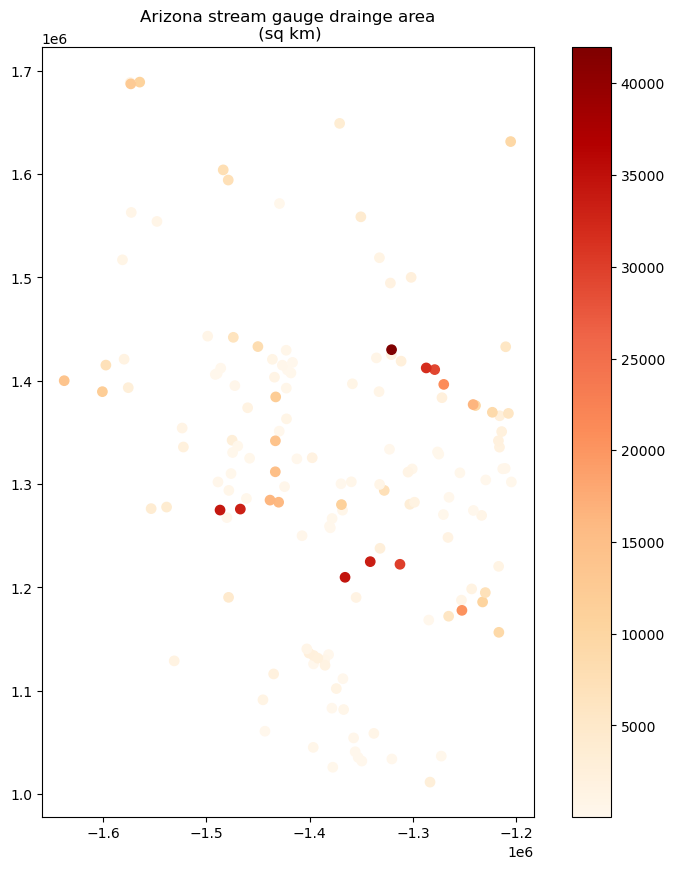

In [6]:
#Coloring our plot by darainage area
fig, ax = plt.subplots(figsize=(10, 10))
gages_AZ.plot(column='DRAIN_SQKM', categorical=False, 
                legend=True, markersize=45, cmap='OrRd',
                ax=ax)
ax.set_title("Arizona stream gauge drainge area\n (sq km)")
plt.show()

## Working with Multiple Datasets: HUC Boundaries

1. Download HUC boundaries from the [USGs National Map Downloader](https://apps.nationalmap.gov/downloader/#/)

2. Under **Hydrography** select 
- Watershed Boundary Dataset (WBD)
- Then HU-2 Region 
- File GDB

3. Scroll back to the top and select search and then pick a HUC2 dataset to download. 

4. Save your downloaded dataset to your codespace


*Note: You can also browse datasets with the [National Map Viewer](https://www.usgs.gov/programs/national-geospatial-program/national-map)*


In [7]:
# Example reading in a geodataframe from a GDB file
file = os.path.join('Data', 'WBD_15_HU2_GDB.gdb')
    #/workspaces/hwrs564b_course_materials_tracy/mywork/content_weekly/Week7_Geospatial/Data/WBD_15_HU2_GDB.gdb

# This will list all the layers in that file
fiona.listlayers(file)

# Read the HUC4 layer
HUC4 = gpd.read_file(file, layer="WBDHU4")

# Read the HUC6 layer
HUC6 = gpd.read_file(file, layer="WBDHU6")

# Check the type and see what we have
print(type(HUC4))
print(HUC4.head())
print(type(HUC6))
print(HUC6.head())

<class 'geopandas.geodataframe.GeoDataFrame'>
                                    tnmid  \
0  {70FEF1CA-E8A1-40E4-807A-2B3774C1186A}   
1  {E364E4BD-50C8-4AD2-93A0-EB813B735DB5}   
2  {C7D39B24-68A5-482B-9EC1-B20FEB452850}   
3  {6CD2178B-03B1-4D2D-9BC5-B1328A200221}   
4  {4E13D9FB-104E-4D30-9A14-A42E627F8725}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
1  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
2  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
3  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
4  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   
1  Natural Resources and Conservation Service and...            

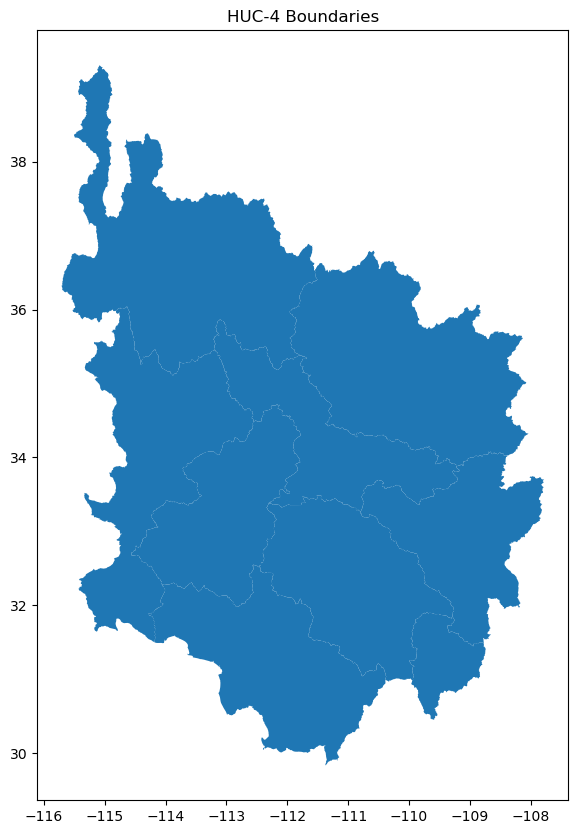

In [8]:
#Plot the HUC4 boundaries (polygon)
fig, ax = plt.subplots(figsize=(10, 10))
HUC4.plot(ax=ax)
ax.set_title("HUC-4 Boundaries")
plt.show()

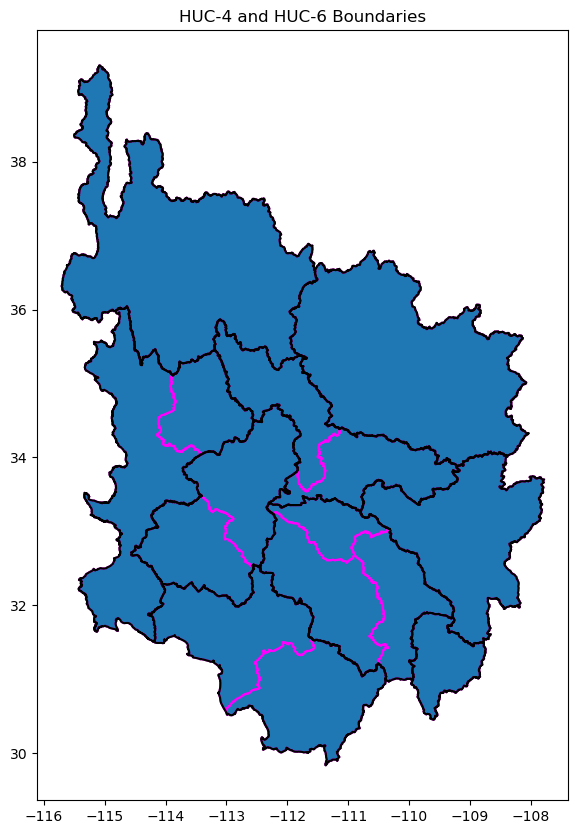

In [9]:
#Plot the HUC6 boundaries (polygon)
fig, ax = plt.subplots(figsize=(10, 10))
HUC6.plot(ax=ax)
HUC6.boundary.plot(ax=ax, color = "magenta")
HUC4.boundary.plot(ax=ax, color = "black")
ax.set_title("HUC-4 and HUC-6 Boundaries")
plt.show()

## GOT TO HERE -- Adding Points to Your Map

Create point features from coordinate pairs and overlay them on your spatial data.

[<POINT (-111.818 33.448)>, <POINT (-111.699 33.515)>]


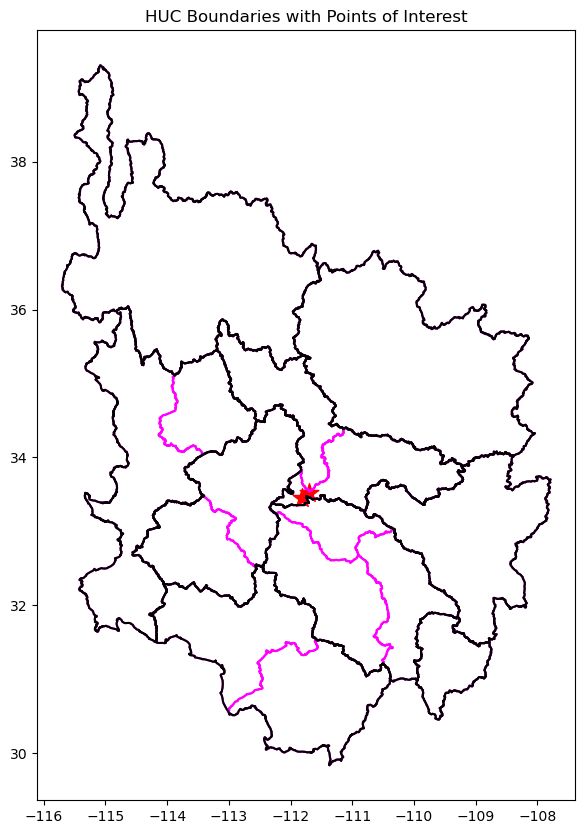

In [10]:
# Define some points
# my house: 33.44822207707735, -111.81830769083015
# Stream gauge #75307 Salt river below granite reef dam: 33.5147, -111.6990
point_list = np.array([[-111.81830769083015, 33.44822207707735],
                       [-111.6990, 33.5147]])    #creating numpy array with sets of lat/longs

# Make these into spatial features  #creating geometry for us
point_geom = [Point(xy) for xy in point_list]
print(point_geom)

# Create a GeoDataFrame of these points     #using projection from watershed
point_df = gpd.GeoDataFrame(point_geom, columns=['geometry'],
                            crs=HUC4.crs)

# Plot these on the HUC dataset
fig, ax = plt.subplots(figsize=(10, 10))
HUC6.boundary.plot(ax=ax, color = "magenta")
HUC4.boundary.plot(ax=ax, color = "black")
point_df.plot(ax=ax, color='red', marker='*', markersize=200)
ax.set_title("HUC Boundaries with Points of Interest")
plt.show()


## Understanding Projections and Coordinate Reference Systems (CRS)

When working with multiple spatial datasets, it's crucial that all your data use the same Coordinate Reference System (CRS). Different datasets may come in different projections, and you need to reproject them to match before combining on a single map.

Reference: [Introduction to Coordinate Reference Systems](https://www.earthdatascience.org/courses/use-data-open-source-python/intro-vector-data-python/spatial-data-vector-shapefiles/intro-to-coordinate-reference-systems-python/)

HUC4 CRS:
EPSG:4269
HUC6 CRS:
EPSG:4269

AZ Stream Gauges CRS:
PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


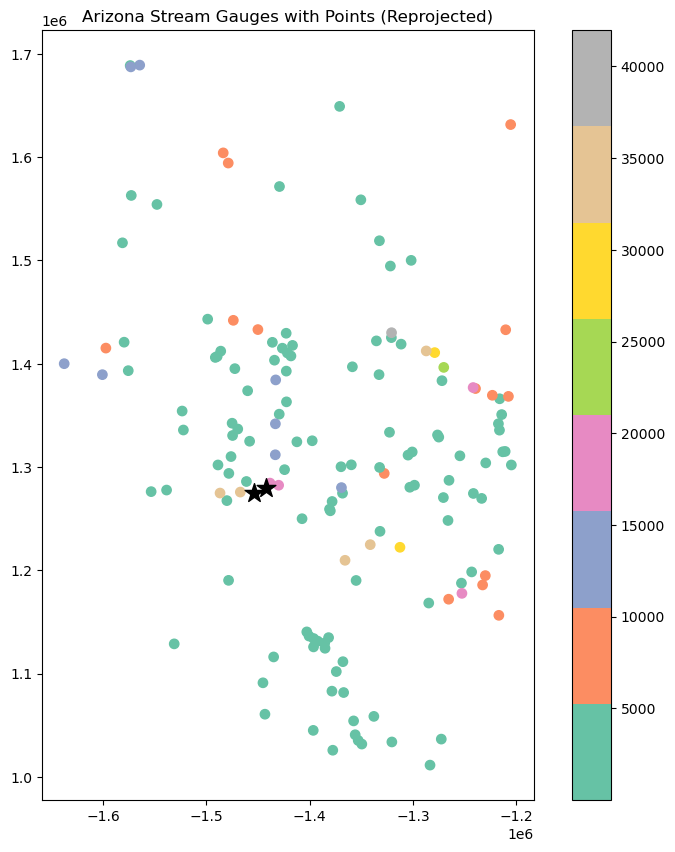

In [11]:
# Check the CRS of different datasets
# always helpful to print out projections and stream gauges
print("HUC4 CRS:")
print(HUC4.crs)
print("HUC6 CRS:")
print(HUC6.crs)
print("\nAZ Stream Gauges CRS:")
print(gages_AZ.crs)

# Notice they are different! We need to reproject our points to match the gauges CRS !!!
points_project = point_df.to_crs(gages_AZ.crs)
# NOTE: .to_crs() will only work if your original spatial object has a CRS assigned 
# to it AND if that CRS is the correct CRS!

# Now plot again with reprojected points
fig, ax = plt.subplots(figsize=(10, 10))
gages_AZ.plot(column='DRAIN_SQKM', categorical=False,
              legend=True, markersize=45, cmap='Set2',
              ax=ax)
points_project.plot(ax=ax, color='black', marker='*', markersize=200)
ax.set_title("Arizona Stream Gauges with Points (Reprojected)")
plt.show()

## Combining Multiple Datasets on One Map

Now let's overlay multiple spatial datasets - stream gauges, points of interest, and watershed boundaries - all on the same map.

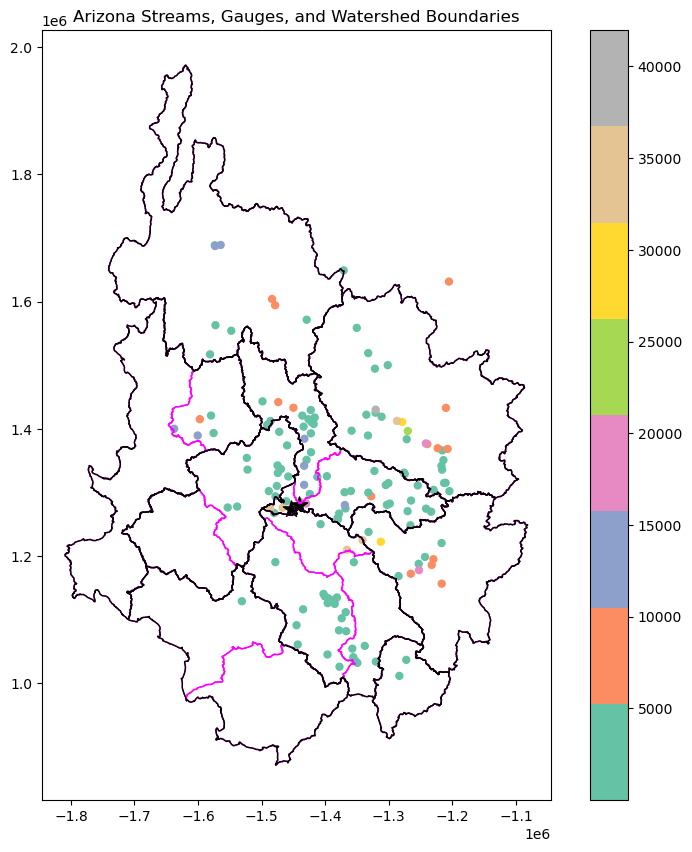

In [12]:
# First, reproject HUC4 and HUC6 to match the other datasets
HUC4_project = HUC4.to_crs(gages_AZ.crs)
HUC6_project = HUC6.to_crs(gages_AZ.crs)

# Now plot all three datasets together
fig, ax = plt.subplots(figsize=(10, 10))

# Plot stream gauges with drainage area colors
gages_AZ.plot(column='DRAIN_SQKM', categorical=False,
              legend=True, markersize=25, cmap='Set2',
              ax=ax)

# Plot points of interest
points_project.plot(ax=ax, color='black', marker='*', markersize=150)

# Plot HUC4 and HUC6 watershed boundaries
HUC6_project.boundary.plot(ax=ax, color=None, 
                           edgecolor='magenta', linewidth=1)
HUC4_project.boundary.plot(ax=ax, color=None, 
                           edgecolor='black', linewidth=1)

ax.set_title("Arizona Streams, Gauges, and Watershed Boundaries")
plt.show()

## Final Map No AI

Use contextily to add a basemap (satellite, streets, terrain, etc.) to your spatial plots. This provides geographic context for your data.

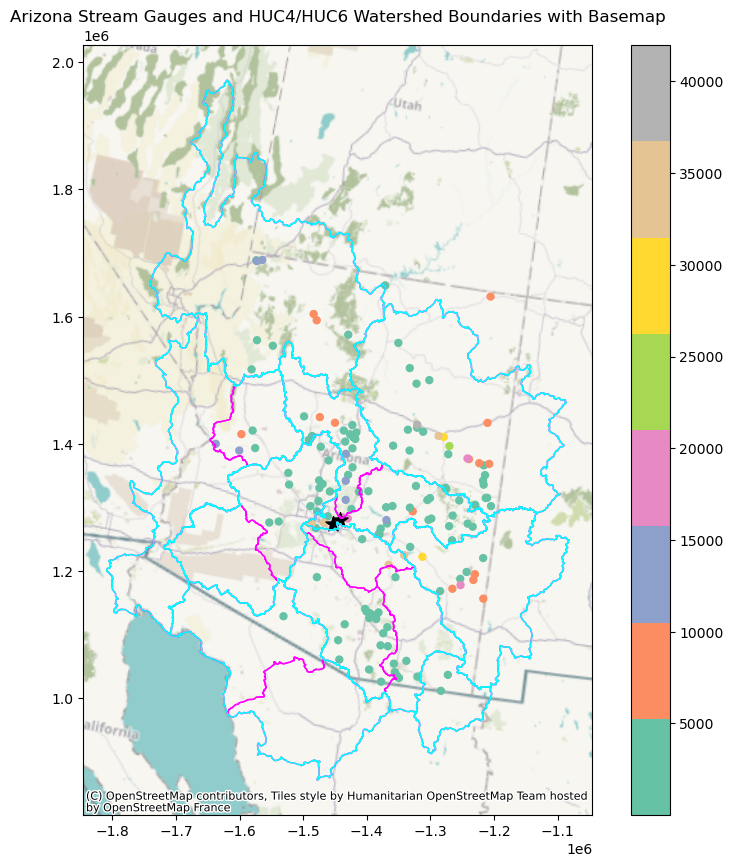

In [13]:
# Create the same map with a basemap background
fig, ax = plt.subplots(figsize=(10, 10))

# Plot stream gauges with drainage area colors
gages_AZ.plot(column='DRAIN_SQKM', categorical=False,
              legend=True, markersize=25, cmap='Set2',
              ax=ax)

# Plot HUC4 and HUC6 watershed boundaries
HUC6_project.boundary.plot(ax=ax, color=None, 
                           edgecolor='magenta', linewidth=1)
HUC4_project.boundary.plot(ax=ax, color=None, 
                           edgecolor='cyan', linewidth=1)

# Plot points of interest
points_project.plot(ax=ax, color='black', marker='*', markersize=130)

# Add basemap - tell it to match the CRS of our data
# Using Contextily package for this (ctx) lots of choices if you play with it
ctx.add_basemap(ax, crs=gages_AZ.crs)

ax.set_title("Arizona Stream Gauges and HUC4/HUC6 Watershed Boundaries with Basemap")
plt.show()

Notes from Laura's class:
In our repo in README, go to our Github (updated regularly). Tells you how to add a package within the command line. New terminal. Note on left that even though we're running in HWRS564b, we're in base. 
run this in terminal: conda env list
conda activate hwrs564b
now you can conda install or pip install
    we need to pip install contextily there into conda

## Claude's help first draft

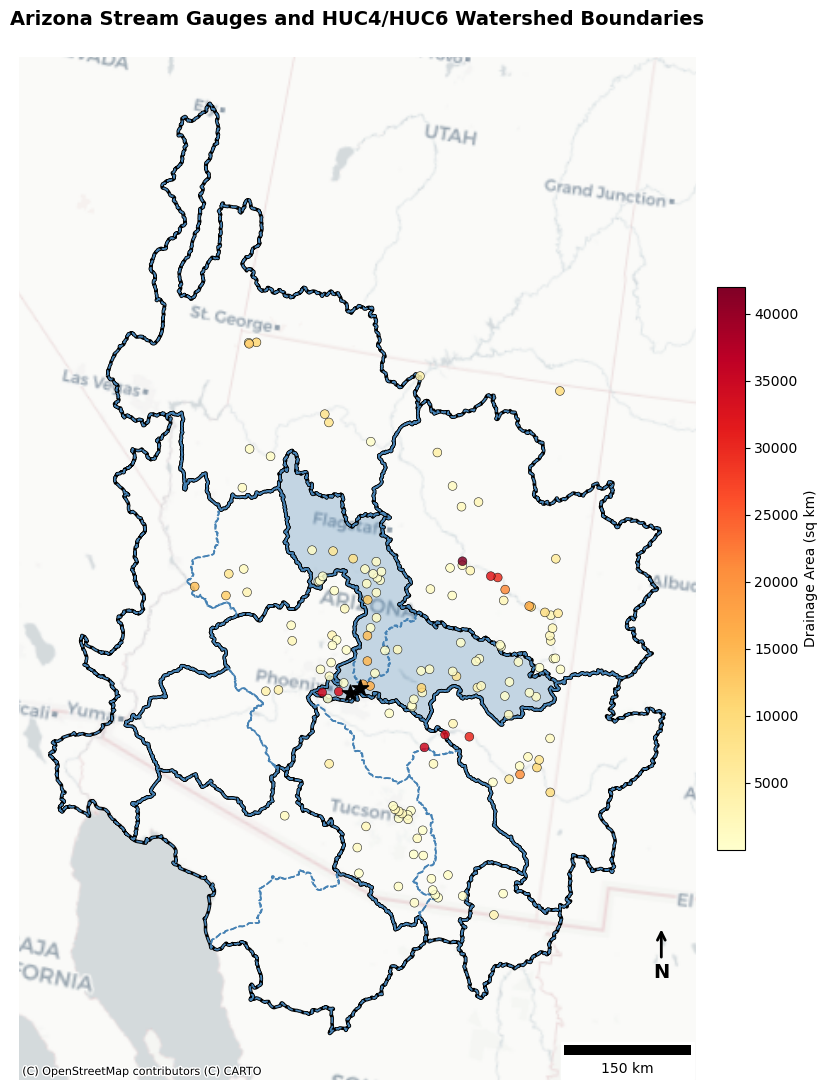

In [23]:
fig, ax = plt.subplots(figsize=(11, 11))

# After ctx.add_basemap(...)
ax.add_artist(ScaleBar(1, location='lower right'))

gages_AZ.plot(
    column='DRAIN_SQKM',
    categorical=False,
    legend=True,
    legend_kwds={'label': 'Drainage Area (sq km)', 'shrink': 0.55, 'pad': 0.02},
    markersize=40,
    cmap='YlOrRd',
    edgecolors='black',
    linewidths=0.4,
    alpha=0.85,
    ax=ax,
    zorder=3
)

#HUC4_project.boundary.plot(ax=ax, edgecolor='steelblue', linewidth=2, zorder=2)
#HUC6_project.boundary.plot(ax=ax, edgecolor='#cc00cc', linewidth=1.2,
#                            linestyle='--', zorder=2)

HUC4_project.boundary.plot(ax=ax, edgecolor='black', linewidth=2.5, zorder=2)
HUC6_project.boundary.plot(ax=ax, edgecolor='steelblue', linewidth=1.2,
                            linestyle='--', zorder=2)

points_project.plot(ax=ax, color='black', marker='*', markersize=150, zorder=4)

HUC4_project[HUC4_project['huc4'] == '1506'].plot(
    ax=ax, color='steelblue', alpha=0.3, zorder=1,
    edgecolor='none')  # suppress the polygon border


ctx.add_basemap(ax, crs=gages_AZ.crs, source=ctx.providers.CartoDB.Positron)
ax.add_artist(ScaleBar(1, location='lower right'))
legend=True,
legend_kwds={'label': 'Drainage Area (sq km)', 'shrink': 0.55, 'pad': 0.02},
ax.annotate('N', xy=(0.95, 0.15), xytext=(0.95, 0.1),
            xycoords='axes fraction',
            ha='center', fontsize=14, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_title("Arizona Stream Gauges and HUC4/HUC6 Watershed Boundaries",
             fontsize=14, fontweight='bold', pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## Add point labels

In [24]:
# Define some points
# my house: 33.44822207707735, -111.81830769083015
# Stream gauge #75307 Salt river below granite reef dam: 33.5147, -111.6990
point_list = np.array([[-111.81830769083015, 33.44822207707735],
                       [-111.6990, 33.5147]])

point_geom = [Point(xy) for xy in point_list]

point_df = gpd.GeoDataFrame(point_geom, columns=['geometry'],
                            crs=HUC4.crs)

# Add names to each point
point_df['name'] = ['My House', 'USGS Gauge 09502960']

## Claude's help final draft

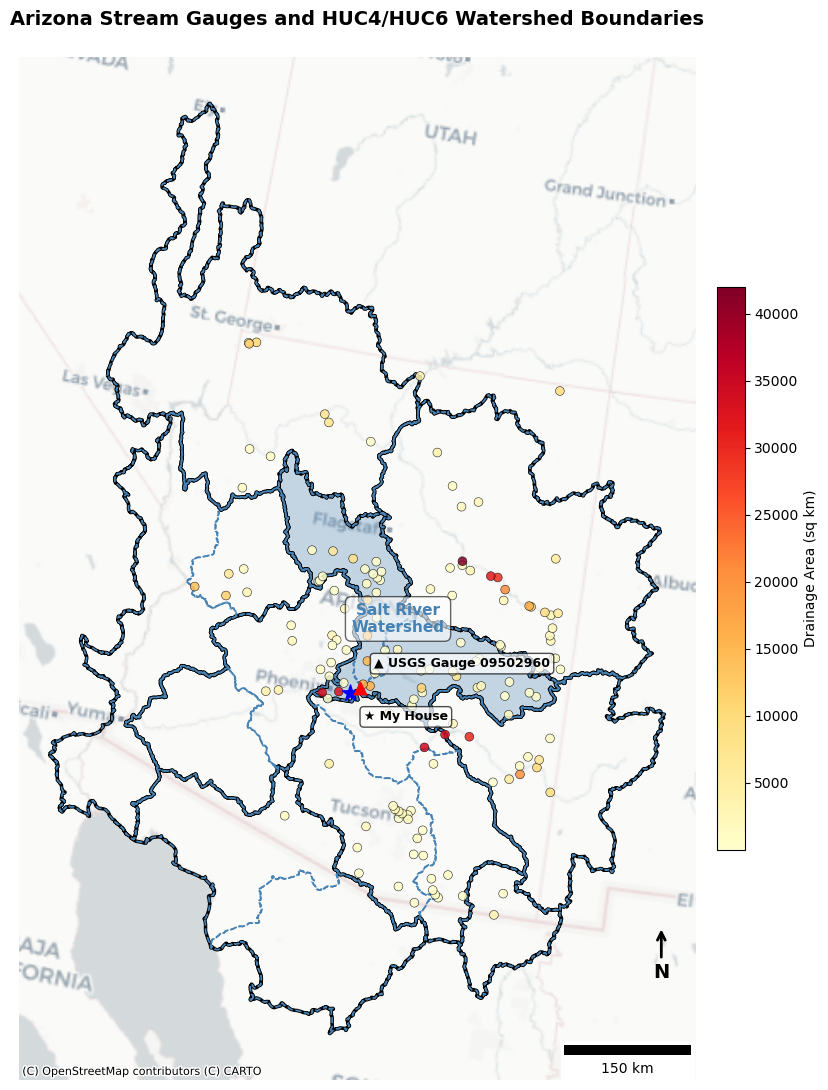

In [40]:
fig, ax = plt.subplots(figsize=(11, 11))

gages_AZ.plot(
    column='DRAIN_SQKM',
    categorical=False,
    legend=True,
    legend_kwds={'label': 'Drainage Area (sq km)', 'shrink': 0.55, 'pad': 0.02},
    markersize=40,
    cmap='YlOrRd',
    edgecolors='black',
    linewidths=0.4,
    alpha=0.85,
    ax=ax,
    zorder=3
)

HUC4_project.boundary.plot(ax=ax, edgecolor='black', linewidth=2.5, zorder=2)
HUC6_project.boundary.plot(ax=ax, edgecolor='steelblue', linewidth=1.2,
                            linestyle='--', zorder=2)

points_project = point_df.to_crs(gages_AZ.crs)  # or however you reproject

# Split into two
house = points_project[points_project['name'] == 'My House']
gauge = points_project[points_project['name'] == 'USGS Gauge 09502960']

# Plot with different markers
house.plot(ax=ax, color='blue', marker='*', markersize=150, zorder=5)
gauge.plot(ax=ax, color='red', marker='^', markersize=80, zorder=5)

# Add labels
ax.annotate('\u25B2 USGS Gauge 09502960',
            xy=(gauge.geometry.x.values[0], gauge.geometry.y.values[0]),
            xytext=(10, 15), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

ax.annotate('\u2605 My House', 
            xy=(house.geometry.x.values[0], house.geometry.y.values[0]),
            xytext=(10, -20), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

HUC4_project[HUC4_project['huc4'] == '1506'].plot(
    ax=ax, color='steelblue', alpha=0.3, zorder=1,
    edgecolor='none')  # suppress the polygon border
salt_river = HUC4_project[HUC4_project['huc4'] == '1506']
centroid = salt_river.geometry.centroid.values[0]

ax.annotate('Salt River\nWatershed',
            xy=(centroid.x, centroid.y),
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='steelblue',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.6))


ctx.add_basemap(ax, crs=gages_AZ.crs, source=ctx.providers.CartoDB.Positron)

ax.add_artist(ScaleBar(1, location='lower right'))

legend=True,
legend_kwds={'label': 'Drainage Area (sq km)', 'shrink': 0.55, 'pad': 0.02},
ax.annotate('N', xy=(0.95, 0.15), xytext=(0.95, 0.1),
            xycoords='axes fraction',
            ha='center', fontsize=14, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_title("Arizona Stream Gauges and HUC4/HUC6 Watershed Boundaries",
             fontsize=14, fontweight='bold', pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()
